# Chrgr Reliability Score Engine — 90-Day Simulation

Generates 90 days of synthetic check-in data for 5 chargers, each with a distinct reliability pattern, computes the daily reliability-score trajectory for each using `ReliabilityScoreEngine`, and plots how scores evolve over time.

**Chargers simulated:**
- `CHRGR-001` — Always Reliable (~99% success throughout)
- `CHRGR-002` — Intermittent Failures (oscillates ~80%→40% success in 20-day cycles)
- `CHRGR-003` — Recently Broken (reliable for 80 days, then fails hard in the last 10)
- `CHRGR-004` — Slow Decline (failure rate ramps steadily from 5% to 55%)
- `CHRGR-005` — Low Traffic (sparse check-ins, tests low-confidence scoring)


## 1. Setup

In [1]:
import sys, random
from datetime import datetime, timedelta, timezone
import matplotlib.pyplot as plt

sys.path.insert(0, '.')
from reliability_engine import Checkin, CheckinResult, ReliabilityScoreEngine

random.seed(42)  # reproducible simulation

SIM_DAYS = 90
SIM_END = datetime(2026, 9, 24, 0, 0, 0, tzinfo=timezone.utc)
SIM_START = SIM_END - timedelta(days=SIM_DAYS)


## 2. Define the 5 charger patterns

In [2]:
def _random_times_on_day(day_start, n):
    """n random check-in timestamps between 06:00-23:00 on the given day."""
    return sorted(day_start + timedelta(hours=random.uniform(6, 23)) for _ in range(n))

def gen_always_works(_):
    """Reliable charger: ~99% success throughout the 90 days."""
    checkins = []
    for d in range(SIM_DAYS):
        day = SIM_START + timedelta(days=d)
        for t in _random_times_on_day(day, random.randint(1, 3)):
            result = CheckinResult.FAILED if random.random() < 0.01 else CheckinResult.WORKED
            checkins.append(Checkin(result, t))
    return checkins

def gen_intermittent(_):
    """Flaky charger: oscillates between ~80% and ~40% success in 20-day cycles."""
    checkins = []
    for d in range(SIM_DAYS):
        day = SIM_START + timedelta(days=d)
        cycle_pos = (d % 20) / 20.0
        fail_rate = 0.2 + 0.4 * abs(cycle_pos - 0.5) * 2
        for t in _random_times_on_day(day, random.randint(1, 3)):
            result = CheckinResult.FAILED if random.random() < fail_rate else CheckinResult.WORKED
            checkins.append(Checkin(result, t))
    return checkins

def gen_recently_broken(_):
    """Reliable for 80 days, then fails hard in the final 10 days."""
    checkins = []
    for d in range(SIM_DAYS):
        day = SIM_START + timedelta(days=d)
        broken = d >= SIM_DAYS - 10
        fail_rate = 0.9 if broken else 0.03
        for t in _random_times_on_day(day, random.randint(1, 3)):
            result = CheckinResult.FAILED if random.random() < fail_rate else CheckinResult.WORKED
            checkins.append(Checkin(result, t))
    return checkins

def gen_slow_decline(_):
    """Gradually degrading charger: failure rate ramps from 5% to 55%."""
    checkins = []
    for d in range(SIM_DAYS):
        day = SIM_START + timedelta(days=d)
        fail_rate = 0.05 + 0.5 * (d / SIM_DAYS)
        for t in _random_times_on_day(day, random.randint(1, 3)):
            result = CheckinResult.FAILED if random.random() < fail_rate else CheckinResult.WORKED
            checkins.append(Checkin(result, t))
    return checkins

def gen_low_traffic(_):
    """Sparse check-ins (~1 every 4 days), decent reliability when checked."""
    checkins = []
    for d in range(SIM_DAYS):
        day = SIM_START + timedelta(days=d)
        if random.random() < 0.25:
            for t in _random_times_on_day(day, 1):
                result = CheckinResult.FAILED if random.random() < 0.15 else CheckinResult.WORKED
                checkins.append(Checkin(result, t))
    return checkins

CHARGERS = {
    "CHRGR-001": ("Always Reliable", gen_always_works),
    "CHRGR-002": ("Intermittent Failures", gen_intermittent),
    "CHRGR-003": ("Recently Broken", gen_recently_broken),
    "CHRGR-004": ("Slow Decline", gen_slow_decline),
    "CHRGR-005": ("Low Traffic", gen_low_traffic),
}
print(f"Defined {len(CHARGERS)} charger patterns.")


Defined 5 charger patterns.


## 3. Run the simulation

For each charger, compute a daily reliability score using only the check-ins visible up to that day (so the trajectory shows how the score would have looked to a driver in real time, not with hindsight).

In [3]:
engine = ReliabilityScoreEngine(decay_constant=0.02)
simulation = {}

for charger_id, (label, generator) in CHARGERS.items():
    checkins = sorted(generator(charger_id), key=lambda c: c.timestamp)

    trajectory = []
    for d in range(SIM_DAYS):
        as_of = SIM_START + timedelta(days=d + 1)
        visible = [c for c in checkins if c.timestamp <= as_of]
        result = engine.compute(visible, as_of=as_of)
        trajectory.append({"day": d, "score": result["score"]})

    final = engine.compute(checkins, as_of=SIM_END)
    simulation[charger_id] = {"label": label, "checkins": checkins, "trajectory": trajectory, "final": final}

print("Simulation complete for:", list(simulation.keys()))


Simulation complete for: ['CHRGR-001', 'CHRGR-002', 'CHRGR-003', 'CHRGR-004', 'CHRGR-005']


## 4. Plot: reliability score over time, all 5 chargers

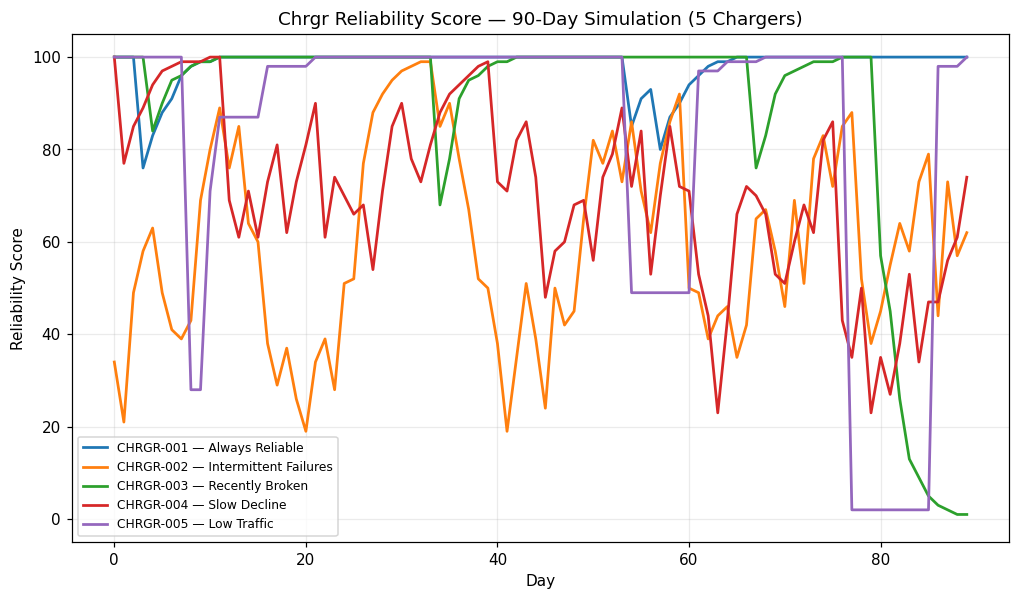

In [4]:
plt.figure(figsize=(11, 6))
for charger_id, data in simulation.items():
    days = [pt["day"] for pt in data["trajectory"]]
    scores = [pt["score"] if pt["score"] is not None else float("nan") for pt in data["trajectory"]]
    plt.plot(days, scores, label=f"{charger_id} — {data['label']}", linewidth=1.8)

plt.title("Chrgr Reliability Score — 90-Day Simulation (5 Chargers)")
plt.xlabel("Day")
plt.ylabel("Reliability Score")
plt.ylim(-5, 105)
plt.legend(loc="lower left", fontsize=8)
plt.grid(alpha=0.25)
plt.show()


## 5. Final scores summary

The score each charger would show *today* (end of the 90-day window), using every check-in collected.

In [5]:
print(f"{'Charger':12s} {'Pattern':24s} {'Score':>6s} {'Confidence':>12s} {'Check-ins':>10s}")
print("-" * 68)
for charger_id, data in simulation.items():
    f = data["final"]
    print(f"{charger_id:12s} {data['label']:24s} {f['score']:>6} {f['confidence']:>12s} {f['total_checkins']:>10}")


Charger      Pattern                   Score   Confidence  Check-ins
--------------------------------------------------------------------
CHRGR-001    Always Reliable             100         high        182
CHRGR-002    Intermittent Failures        62         high        188
CHRGR-003    Recently Broken               1         high        186
CHRGR-004    Slow Decline                 74         high        182
CHRGR-005    Low Traffic                 100         high         22


## Notes

- Decay constant `λ = 0.02` (same default as `reliability_engine.py`) — ≈35h half-life, so a check-in from ~1.5 days ago has already lost half its weight.
- `CHRGR-003` (Recently Broken) is the clearest illustration of why time decay matters: 80 days of perfect service couldn't be seen in a plain average, but barely registers here — the score craters within days of the failures starting.
- `CHRGR-005` (Low Traffic) stays volatile throughout since each individual check-in carries much more weight when there are few of them — exactly what the confidence rating is meant to flag.